In [1]:
# Import all libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Load the dataset
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')

print("Libraries loaded!")
print("Dataset shape:", df.shape)



Libraries loaded!
Dataset shape: (180519, 53)


In [2]:
# Prepare features for ML model
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_year'] = df['order date (DateOrders)'].dt.year
df['order_day'] = df['order date (DateOrders)'].dt.dayofweek

# Select features
features = [
    'order_month',
    'order_year', 
    'order_day',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Late_delivery_risk'
]

target = 'Order Item Quantity'

ml_df = df[features + [target]].dropna()

print("Data prepared for ML!")
print("Total samples:", len(ml_df))

Data prepared for ML!
Total samples: 180519


In [3]:
# Split data into training and testing
X = ml_df[features]
y = ml_df[target]

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Train the Random Forest ML model
print("\nTraining ML model... please wait!")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test the model
predictions = model.predict(X_test)

# Check accuracy
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n✅ Model Training Complete!")
print(f"Model Accuracy (R² Score): {r2:.2%}")
print(f"Average Error: {mae:.2f} units")

Training samples: 144415
Testing samples: 36104

Training ML model... please wait!

✅ Model Training Complete!
Model Accuracy (R² Score): 29.95%
Average Error: 0.77 units


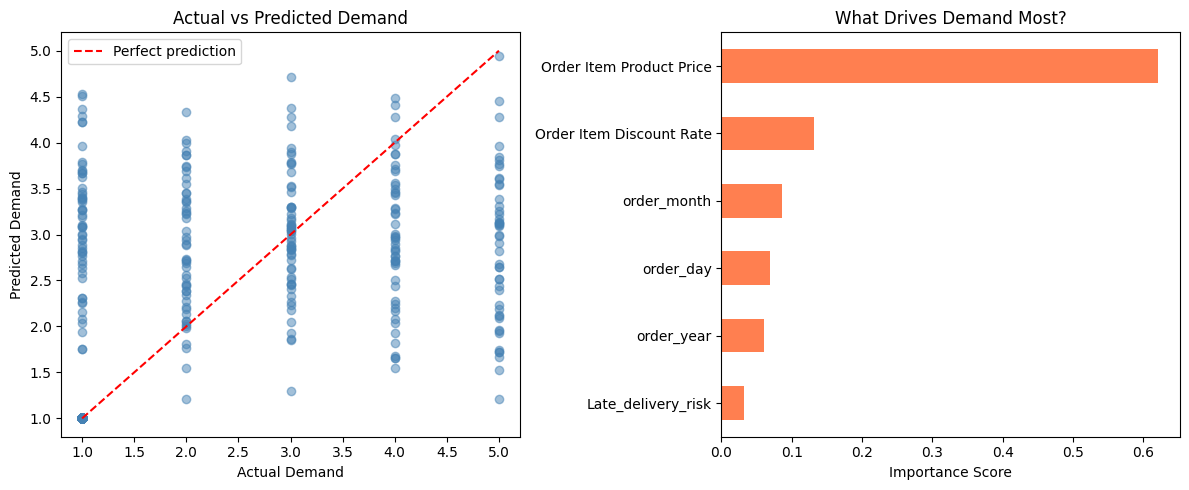


Top factor driving demand: Order Item Product Price


In [4]:
# Compare actual vs predicted demand
plt.figure(figsize=(12, 5))

# Plot actual vs predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test[:500], predictions[:500], alpha=0.5, color='steelblue')
plt.plot([1, 5], [1, 5], 'r--', label='Perfect prediction')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted Demand')
plt.legend()

# Plot feature importance
plt.subplot(1, 2, 2)
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', color='coral')
plt.title('What Drives Demand Most?')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()

print("\nTop factor driving demand:", importance.idxmax())